# Project Z: Modeling Epidemic Dynamics with Cellular Automata and Convolutions

## Introduction
In this project, we simulate the spread of a theoretical virus (or a zombie outbreak) using **Cellular Automata**. Instead of using traditional agent-based modeling with inefficient loops, we utilize **Linear Algebra** and **Signal Processing** techniques.

Specifically, we treat the city map as a matrix and use **2D Convolutions** to calculate interactions between neighbors. This allows us to simulate populations of thousands of agents efficiently in pure Python.

### The Rules (SZR Model)
1.  **Susceptible (0):** Healthy humans.
2.  **Zombie (1):** Infected agents.
3.  **Removed (Empty):** Dead agents or empty space.

The state of a cell in the next timestamp depends on the state of its **8 immediate neighbors** (Moore Neighborhood).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import convolve2d
from matplotlib import animation, rc
from IPython.display import HTML

# Configure visualization style
sns.set_theme(style="white")
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## 1. The Math: Vectorized Neighbor Counting

To determine if a Human becomes a Zombie, we need to know how many Zombies surround them. In a standard loop approach, we would check pixels `(i-1, j-1)`, `(i, j-1)`, etc. 

In this approach, we use a **Convolution Kernel**. 

We create a $3 \times 3$ filter that looks like this:
$$
K = \begin{bmatrix} 
1 & 1 & 1 \\ 
1 & 0 & 1 \\ 
1 & 1 & 1 
\end{bmatrix}
$$

When we convolve our city matrix with this kernel, the operation sums the values of the neighbors for every single cell simultaneously.

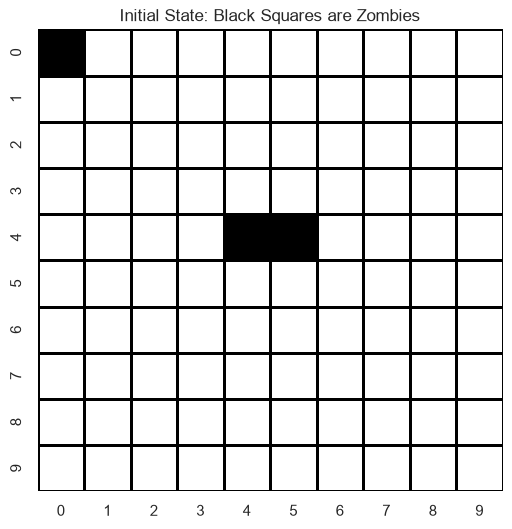

In [2]:
# 1. Define the Kernel (The "Neighbor Counter")
# This kernel represents the Moore Neighborhood (8 surrounding cells)
kernel = np.array([[1, 1, 1],
                   [1, 0, 1],
                   [1, 1, 1]])

# 2. Create a small Test Grid (10x10) to verify logic
# 0 = Human, 1 = Zombie
grid_size = 10
test_grid = np.zeros((grid_size, grid_size))

# 3. Patient Zero: Let's place 3 zombies in specific locations
test_grid[4, 4] = 1 # Center
test_grid[4, 5] = 1 # Right of center
test_grid[0, 0] = 1 # Corner case

# Visualization
plt.figure(figsize=(6, 6))
sns.heatmap(test_grid, cmap="Greys", cbar=False, linewidths=1, linecolor='black')
plt.title("Initial State: Black Squares are Zombies")
plt.show()

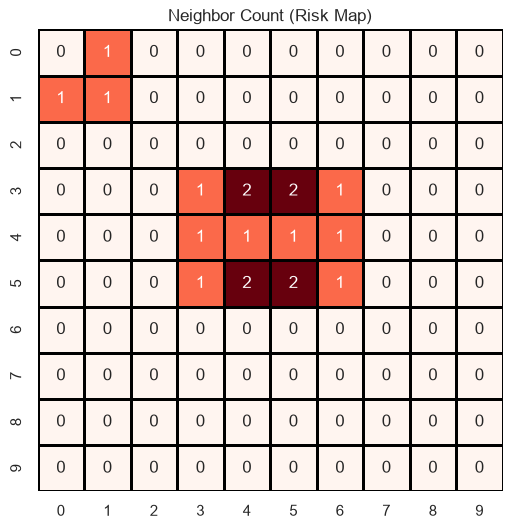

In [3]:
# Apply the convolution to count neighbors
# mode='same' ensures the output matrix is the same size as the input
neighbor_count = convolve2d(test_grid, kernel, mode='same')

# Let's visualize the "Risk Map"
plt.figure(figsize=(6, 6))
sns.heatmap(neighbor_count, annot=True, cbar=False, cmap="Reds", linewidths=1, linecolor='black')
plt.title("Neighbor Count (Risk Map)")
plt.show()

### Important Note on the Kernel
You might notice that the Zombie at `(0,0)` has a neighbor count of **0**, while the Zombies at `(4,4)` and `(4,5)` have a count of **1**.

Why? Look at our Kernel again:
The **center value is 0**.
$$
K = \begin{bmatrix} 
1 & 1 & 1 \\ 
1 & 0 & 1 \\ 
1 & 1 & 1 
\end{bmatrix}
$$

This means the convolution does not count the cell itself, it strictly counts the surrounding neighbors.

### Analysis of the Risk Map

Look at the heatmap above (The Red Grid). 
* The numbers represent **how many zombies are touching that square**.
* A cell with a `0` is safe (for now).
* A cell with a high number (e.g., 2 or 3) is in high danger of infection.

We achieved this count for the entire grid in **one single line of code**, without a single `for` loop. This is the power of vectorization.

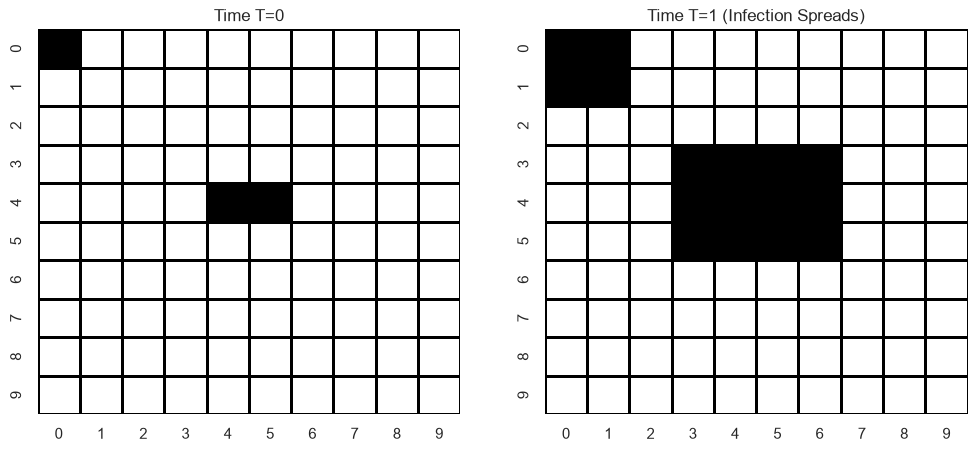

In [4]:
# 1. Identify where infection happens
infection_mask = (test_grid == 0) & (neighbor_count > 0)

# 2. Apply infection
# We copy the grid to next_grid so we don't mess up the current state while calculating
next_grid = test_grid.copy()
next_grid[infection_mask] = 1

# Visualization of the Spread
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(test_grid, ax=ax[0], cmap="Greys", cbar=False, linewidths=1, linecolor='black')
ax[0].set_title("Time T=0")

sns.heatmap(next_grid, ax=ax[1], cmap="Greys", cbar=False, linewidths=1, linecolor='black')
ax[1].set_title("Time T=1 (Infection Spreads)")

plt.show()

## 2. Introducing Stochasticity (The SIR Model)

Real epidemics are not deterministic; they are **probabilistic**.
To make our simulation realistic, we introduce the **SIR Model** states and random chance.

### States:
* **0 (Susceptible):** Healthy humans.
* **1 (Infected):** Zombies.
* **2 (Removed):** Dead/Empty (cannot be infected, cannot infect others).

### Rules of Engagement:
1.  **Infection Chance ($P_i$):** If a human has a zombie neighbor, they don't turn instantly. They roll a die. If the roll is lower than $P_i$, they turn.
2.  **Death Chance ($P_d$):** Every turn, a zombie has a small chance of "dying" (decaying or being eliminated).

In [5]:
# State Constants
HUMAN = 0
ZOMBIE = 1
DEAD = 2

# Simulation Parameters (Hyperparameters)
ALPHA = 0.4  # Infection probability (40% chance if neighbor is zombie)
BETA  = 0.1  # Decay/Death probability (10% chance a zombie dies per step)

### The `simulation_step` Function

Instead of iterating through the grid with `for` loops (which is slow), we generate a **matrix of random numbers** the same size as our grid.

1.  **Risk Matrix:** We calculate neighbor counts using convolution.
2.  **Dice Roll:** We generate a matrix of random floats between 0 and 1.
3.  **Infection Mask:** (Is Human?) AND (Has Zombie Neighbor?) AND (Random Roll < $P_i$?)
    * **Death Mask:** (Is Zombie?) AND (Random Roll < $P_d$?)

In [6]:
def simulation_step(current_grid):
    """
    Computes the next state of the grid based on the SIR rules.
    """
    # 1. Count Zombie Neighbors
    # We only care about neighbors that are strictly ZOMBIES (state == 1)
    zombie_mask = (current_grid == ZOMBIE).astype(int) 
    neighbor_count = convolve2d(zombie_mask, kernel, mode='same')
    
    # 2. Roll the Dice (Generate randomness for the whole grid)
    # This creates a matrix of random numbers between 0.0 and 1.0
    random_rolls = np.random.random(current_grid.shape)
    
    # 3. Rule 1: Infection (Human -> Zombie)
    # Conditions: Is Human AND Has Zombie Neighbor AND Roll < Alpha
    human_mask = (current_grid == HUMAN)
    risk_mask  = (neighbor_count > 0)
    infection_trigger = (random_rolls < ALPHA)
    
    # Combine conditions
    new_infections = human_mask & risk_mask & infection_trigger
    
    # 4. Rule 2: Death (Zombie -> Dead)
    # Conditions: Is Zombie AND Roll < Beta
    death_trigger = (random_rolls < BETA)
    new_deaths = zombie_mask.astype(bool) & death_trigger
    
    # 5. Update the Grid
    next_grid = current_grid.copy()
    
    # Apply changes
    next_grid[new_infections] = ZOMBIE
    next_grid[new_deaths] = DEAD
    
    return next_grid

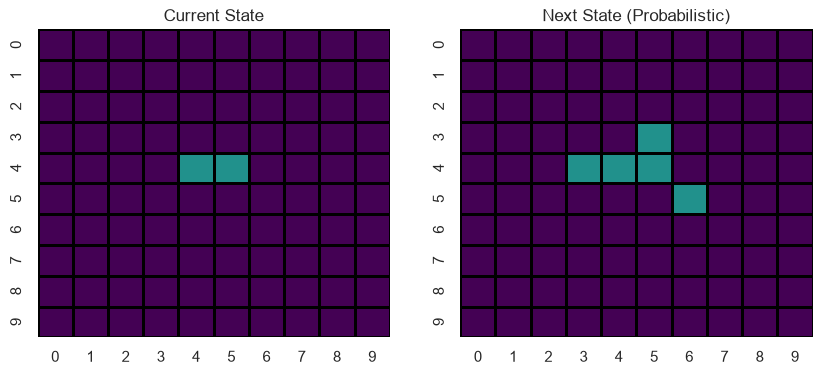

In [7]:
# Let's test the function on our small 10x10 grid from before

# Reset the grid for the test
test_grid = np.zeros((grid_size, grid_size))
test_grid[4, 4] = ZOMBIE
test_grid[4, 5] = ZOMBIE

# Run one step
next_step_grid = simulation_step(test_grid)

# Visualize Before vs After
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot Original
sns.heatmap(test_grid, ax=ax[0], cmap="viridis", cbar=False, linewidths=1, linecolor='black', vmin=0, vmax=2)
ax[0].set_title("Current State")

# Plot Next Step
# We fix vmin=0 and vmax=2 to keep colors consistent (0=Purple, 1=Green, 2=Yellow/Blue depending on map)
sns.heatmap(next_step_grid, ax=ax[1], cmap="viridis", cbar=False, linewidths=1, linecolor='black', vmin=0, vmax=2)
ax[1].set_title("Next State (Probabilistic)")

plt.show()

## 3. The Time Loop: Simulating the Outbreak

Now we scale up. We will create a function `simulate_epidemic` that runs the simulation for a specific number of days.

### Data Strategy: The History List
To create an animation later, we cannot just overwrite the grid every step. We need to **record history**.
* We will create a list called `history`.
* At every step `t`, we take a snapshot of the grid (using `.copy()`) and append it to the list.
* At the end, we will have a 3D structure (Time, Height, Width) representing the entire timeline of the apocalypse.

In [8]:
def simulate_epidemic(N, days, initial_zombies=5):
    """
    Runs the full simulation.
    N: Grid size (N x N)
    days: Number of time steps
    initial_zombies: Number of patients zero
    """
    # 1. Initialize the City (All Humans)
    grid = np.zeros((N, N))
    
    # 2. Plant Patient Zeroes randomly
    # We choose random coordinates
    random_indices = np.random.choice(N*N, initial_zombies, replace=False)
    # Convert flat indices to (x, y) coordinates
    coords = np.unravel_index(random_indices, (N, N))
    grid[coords] = ZOMBIE
    
    # 3. History Container
    # We will store every frame here to animate later
    history = [grid.copy()]
    
    # 4. The Time Loop
    curr_grid = grid.copy()
    for t in range(days):
        # Run our vectorized step function
        curr_grid = simulation_step(curr_grid)
        history.append(curr_grid.copy())
        
    return history

### Visuals: Custom Colormap
The default colors are confusing. Let's define a specific palette for our Movie:

* **Human (0):** Light Gray (`#dedede`) - Represents normality.
* **Zombie (1):** Bright Red (`#ff3b3b`) - Represents danger.
* **Dead (2):** Pure Black (`#000000`) - Represents the void.

In [9]:
from matplotlib.colors import ListedColormap

# Define our custom palette
# Map logic: 0 -> Gray, 1 -> Red, 2 -> Black
cMap = ListedColormap(['#dedede', '#ff3b3b', '#000000'])

### Running the Simulation
Let's run a large-scale simulation.
* **Grid:** 100 x 100 (10,000 agents).
* **Duration:** 150 Days.
* **Patients Zero:** 3 initial infections.

*Note: This might take a second to calculate, but thanks to vectorization, it's blazing fast compared to Python loops.*

In [10]:
# Parameters
GRID_SIZE = 100
DAYS = 150
PATIENTS_ZERO = 3

# Run the simulation engine
history = simulate_epidemic(N=GRID_SIZE, days=DAYS, initial_zombies=PATIENTS_ZERO)

### The Movie: Rendering the Animation
We use `matplotlib.animation` to stitch the `history` frames into a video.
We verify the title dynamically to count the survivors in real-time.

In [11]:
import warnings
# Suppress specific matplotlib font warnings to keep the output clean
warnings.filterwarnings("ignore", category=UserWarning)

# Create the figure
fig, ax = plt.subplots(figsize=(8, 8))
plt.close() # Prevents double display

# Initial setup
# vmin=0, vmax=2 is CRITICAL to ensure colors don't shift
img = ax.imshow(history[0], cmap=cMap, interpolation='nearest', vmin=0, vmax=2)
ax.axis('off')

def animate(frame_idx):
    """Update function for the animation"""
    # Update grid
    img.set_data(history[frame_idx])
    
    # Calculate stats for the title
    current_state = history[frame_idx]
    zombies = np.sum(current_state == ZOMBIE)
    dead = np.sum(current_state == DEAD)
    # Humans = Total - (Zombies + Dead)
    humans = (GRID_SIZE * GRID_SIZE) - zombies - dead
    
    # Clean Title without Emojis to avoid warnings
    ax.set_title(f"Day {frame_idx} | Zombies: {zombies} | Dead: {dead} | Humans: {humans}")
    return [img]

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=len(history), interval=60, blit=True)

# Display as HTML5 Video
HTML(anim.to_jshtml())

## 4. Analysis: The SZR Curves

Visualization is great, but data science is about metrics.
Let's plot the population counts over time to understand the dynamics of the outbreak.
We want to answer:
1. **Peak Infection:** On which day did we have the maximum number of active zombies?
2. **Survival Rate:** Did humanity go extinct?

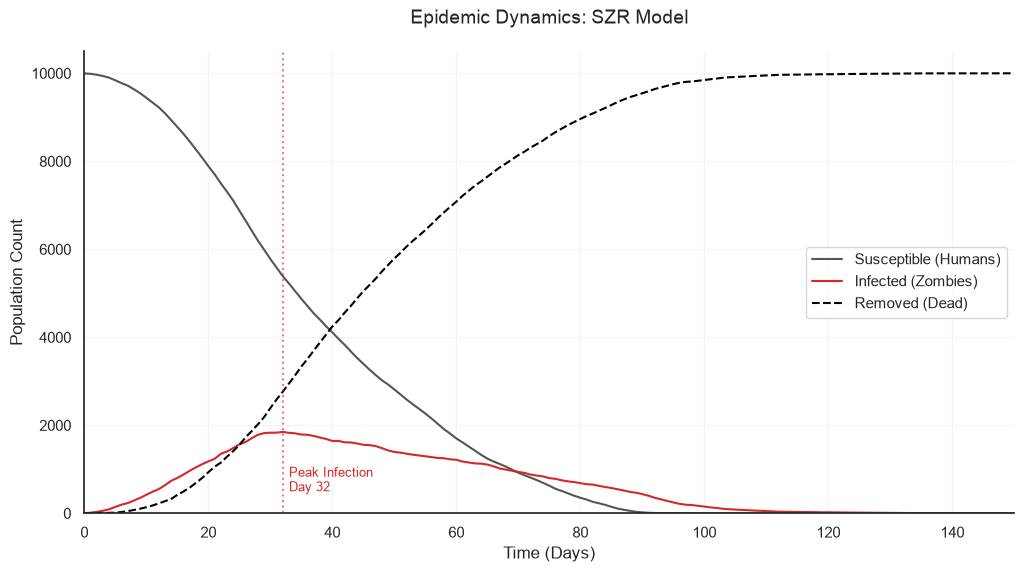

In [12]:
# 1. Setup Data
human_counts = []
zombie_counts = []
dead_counts = []

for grid in history:
    unique, counts = np.unique(grid, return_counts=True)
    counts_dict = dict(zip(unique, counts))
    human_counts.append(counts_dict.get(HUMAN, 0))
    zombie_counts.append(counts_dict.get(ZOMBIE, 0))
    dead_counts.append(counts_dict.get(DEAD, 0))

# 2. Professional Plotting
plt.figure(figsize=(12, 6))

plt.plot(human_counts, label="Susceptible (Humans)", color="#555555", linewidth=1.5) 
plt.plot(zombie_counts, label="Infected (Zombies)", color="#d62728", linewidth=1.5, linestyle="-") 
plt.plot(dead_counts, label="Removed (Dead)", color="black", linewidth=1.5, linestyle="--")

# 3. Peak Marker on X-Axis
peak_day = np.argmax(zombie_counts)
peak_val = zombie_counts[peak_day]

# Vertical line to mark the day
plt.axvline(x=peak_day, color='#d62728', linestyle=':', alpha=0.6)
# Text label on the X-axis
plt.text(peak_day + 1, +500, f"Peak Infection\nDay {peak_day}", color='#d62728', fontsize=9, ha='left')

# Styling
plt.title("Epidemic Dynamics: SZR Model", fontsize=14, pad=20)
plt.ylabel("Population Count")
plt.xlabel("Time (Days)")
plt.legend(loc="center right")
plt.grid(True, alpha=0.2, linestyle='-')
plt.xlim(0, DAYS)
plt.ylim(0, GRID_SIZE*GRID_SIZE + 500) 
sns.despine() 

plt.show()

## 5. Advanced Metrics: Infection Velocity

Beyond total counts, it is crucial to understand the **Speed of the Outbreak**. 
We calculate the **Daily New Infections** (the derivative of the infection curve). This tells us when the virus was most aggressive.

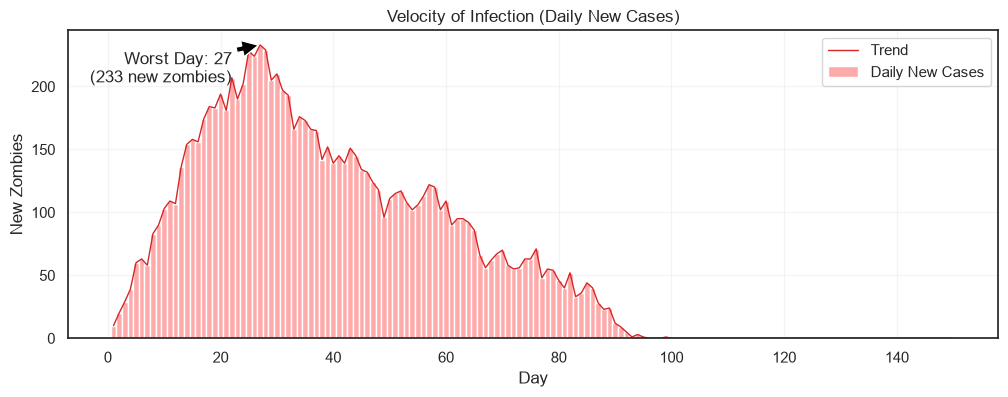

In [13]:
# Calculate new infections per day
new_infections_per_day = []

for t in range(1, len(history)):
    prev_day = history[t-1]
    curr_day = history[t]
    
    # Logic: A cell is a "New Infection" if it was Human yesterday (0) AND is Zombie today (1)
    new_cases_mask = (prev_day == 0) & (curr_day == 1)
    new_infections_per_day.append(np.sum(new_cases_mask))

# Plotting the "Epidemic Curve" (Daily Cases)
plt.figure(figsize=(12, 4))
plt.bar(range(1, len(history)), new_infections_per_day, color='#ffaaaa', width=1.0, label="Daily New Cases")
plt.plot(range(1, len(history)), new_infections_per_day, color='#d62728', linewidth=1, label="Trend")

# Max velocity annotation
max_new_cases = np.max(new_infections_per_day)
day_max_cases = np.argmax(new_infections_per_day) + 1

plt.annotate(
    f'Worst Day: {day_max_cases}\n({max_new_cases} new zombies)',
    xy=(day_max_cases, max_new_cases),
    # Move the label a bit more to the right (smaller left shift)
    xytext=(max(day_max_cases - 5, 1), max_new_cases * 0.98),
    ha='right',
    va='top',
    arrowprops=dict(facecolor='black', shrink=0.05, connectionstyle="arc3,rad=0.0")
)

plt.title("Velocity of Infection (Daily New Cases)")
plt.xlabel("Day")
plt.ylabel("New Zombies")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## 6. Post-Apocalyptic Report

What is the final state of the world?
* **Lucky Survivors:** Humans who, by pure chance or isolation, were never infected.
* **Active Threat:** Zombies still roaming the map at the end of the simulation.
* **Casualties:** Total population lost.

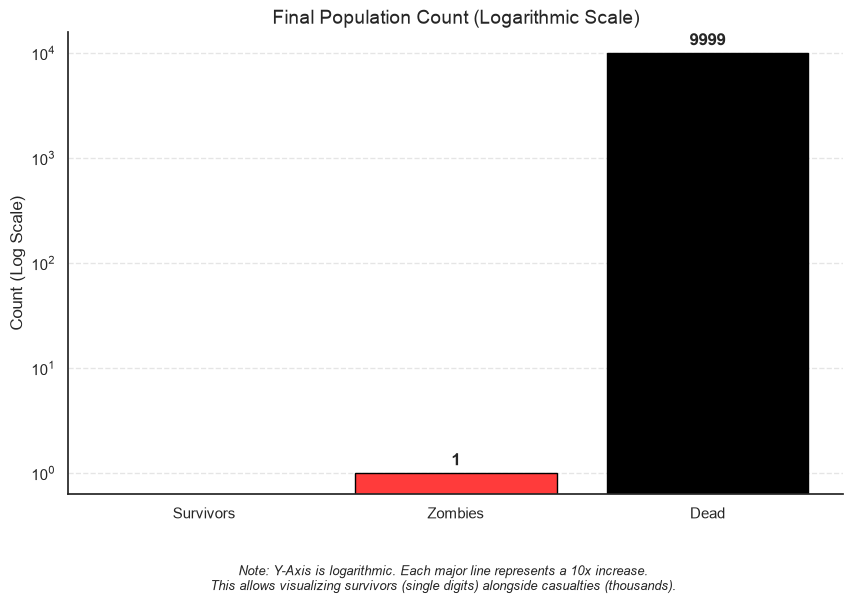

--- FINAL STATS ---
Survivors: 0
Zombies:   1
Dead:      9999


In [14]:
# Get Data
final_grid = history[-1]
final_humans = np.sum(final_grid == HUMAN)
final_zombies = np.sum(final_grid == ZOMBIE)
final_dead = np.sum(final_grid == DEAD)

# Data for plotting
categories = ['Survivors', 'Zombies', 'Dead']
counts = [final_humans, final_zombies, final_dead]
colors = ['#dedede', '#ff3b3b', '#000000'] # Gray, Red, Black

# Setup Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=colors, edgecolor='black')

# Logarithmic Scale 
# This allows us to see "3" and "9992" clearly on the same chart
plt.yscale('log') 

# Add Labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                     f'{int(height)}',
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

add_labels(bars)

plt.title("Final Population Count (Logarithmic Scale)", fontsize=14)
plt.ylabel("Count (Log Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.5, which='major')

# Add a text explanation for the viewer
plt.figtext(0.5, -0.05, 
            "Note: Y-Axis is logarithmic. Each major line represents a 10x increase.\nThis allows visualizing survivors (single digits) alongside casualties (thousands).", 
            ha="center", fontsize=9, style='italic')

sns.despine()
plt.show()

print(f"--- FINAL STATS ---")
print(f"Survivors: {final_humans}")
print(f"Zombies:   {final_zombies}")
print(f"Dead:      {final_dead}")

## 7. Complex Systems & Heterogeneity

We are upgrading the simulation to mimic real-world complexity. We introduce three advanced concepts:

1.  **Gaussian Population Distribution (Stats):** Not all humans are equal. We assign a "Defense/Strength" attribute to every agent following a **Normal Distribution** ($\mu=0.5, \sigma=0.15$). Some are vulnerable, others are "Heroes" capable of fighting back.
2.  **Spatial Heterogeneity (Terrain):** The map now has a "Hospital/Bunker" zone. Agents in this zone receive a defense bonus.
3.  **Viral Mutation (Time-Series):** The virus is not static. The infection rate (`ALPHA`) will increase over time, simulating mutation.

In [15]:
# Configuration for 2.0
GRID_SIZE = 100
HOSPITAL_RADIUS = 15
CENTER = GRID_SIZE // 2

# 1. Feature A: The Defense Matrix (Gaussian Distribution)
# Mean = 0.5, Std Dev = 0.15. 
# Most people are average, some are weak (0.2), some are strong (0.8)
raw_defense = np.random.normal(loc=0.5, scale=0.15, size=(GRID_SIZE, GRID_SIZE))
defense_grid = np.clip(raw_defense, 0.1, 0.9) # Clip to keep valid probabilities

# 2. Feature B: The Terrain Matrix (The Hospital)
# We create a mask for a circular zone in the center
y, x = np.ogrid[:GRID_SIZE, :GRID_SIZE]
dist_from_center = np.sqrt((x - CENTER)**2 + (y - CENTER)**2)
hospital_mask = dist_from_center <= HOSPITAL_RADIUS

# Apply Bonus: People in the hospital get +0.3 Defense boost
terrain_bonus = np.zeros((GRID_SIZE, GRID_SIZE))
terrain_bonus[hospital_mask] = 0.3

# Final Effective Defense Map
total_defense = np.clip(defense_grid + terrain_bonus, 0, 1.0)

print(f"Average Defense in City: {np.mean(defense_grid):.3f}")
print(f"Average Defense in Hospital: {np.mean(total_defense[hospital_mask]):.3f}")

Average Defense in City: 0.499
Average Defense in Hospital: 0.780


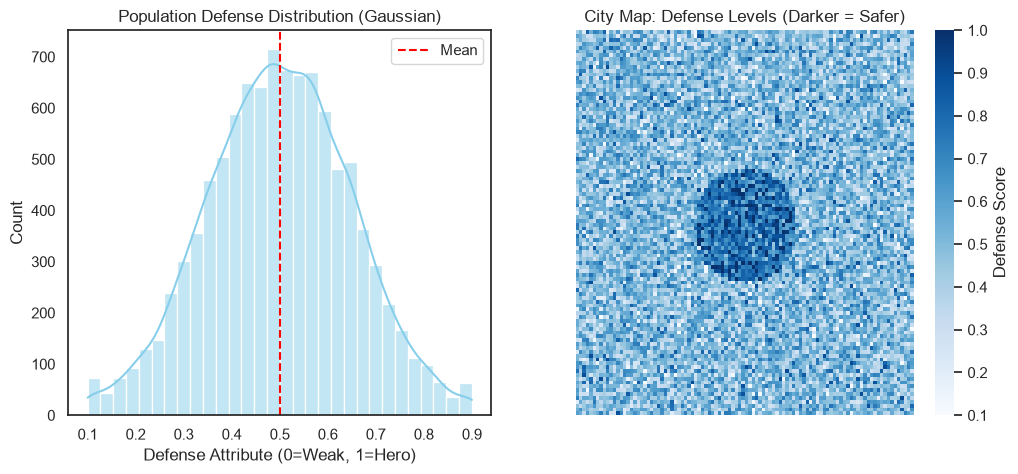

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: The Bell Curve (Gaussian Distribution of Defense)
sns.histplot(defense_grid.flatten(), kde=True, ax=ax[0], color="skyblue", bins=30)
ax[0].set_title("Population Defense Distribution (Gaussian)")
ax[0].set_xlabel("Defense Attribute (0=Weak, 1=Hero)")
ax[0].axvline(0.5, color='red', linestyle='--', label="Mean")
ax[0].legend()

# Plot 2: The Terrain Map
sns.heatmap(total_defense, ax=ax[1], cmap="Blues", cbar_kws={'label': 'Defense Score'})
ax[1].set_title("City Map: Defense Levels (Darker = Safer)")
ax[1].axis('off')

plt.show()

### The New Engine: Combat & Mutation

We rewrite `simulation_step` with complex logic:

1.  **Viral Mutation:** Every day, the infection rate (`ALPHA`) increases slightly.
2.  **The Combat Check:**
    * Instead of a flat probability, we compare `Zombie Attack` vs `Human Defense`.
    * **Infection:** If `Attack > Defense` $\rightarrow$ Human turns.
    * **Counter-Attack (New):** If `Defense` is very high, the Human **kills the Zombie** (The zombie moves to `DEAD` state instantly).

In [17]:
def complex_simulation_step(current_grid, step_num, defense_map, rng):
    """
    Advanced step with Mutation and Combat.
    """
    # --- 1. DYNAMIC MUTATION (Feature C) ---
    # Virus gets stronger every day. Max cap at 0.8
    current_alpha = min(0.3 + (step_num * 0.002), 0.8) 
    
    # Zombie Decay rate (BETA)
    current_beta = 0.05 
    
    # --- 2. PREPARE MATRICES ---
    zombie_mask = (current_grid == ZOMBIE).astype(int)
    neighbor_count = convolve2d(zombie_mask, kernel, mode='same')
    
    infection_rolls = rng.random(current_grid.shape)
    combat_rolls = rng.random(current_grid.shape)
    decay_rolls = rng.random(current_grid.shape)
    
    # --- 3. INFECTION LOGIC (Attack vs Defense) ---
    # Human must have neighbors to be at risk
    risk_mask = (current_grid == HUMAN) & (neighbor_count > 0)
    
    # The Infection Roll:
    # We modify the roll based on Human Defense.
    # Higher Defense = Harder to get infected (requires lower random roll)
    # Formula: Infection happens if Random < (Alpha - Defense_Factor)
    # We scale defense by 0.5 so it doesn't make everyone immune.
    effective_infection_prob = np.clip(current_alpha - (defense_map * 0.4), 0.0, 1.0)
    
    infection_trigger = risk_mask & (infection_rolls < effective_infection_prob)
    
    # --- 4. COMBAT MECHANIC (Feature A: Humans Fighting Back) ---
    # If a Human is attacked but NOT infected, AND has High Defense (> 0.7),
    # they might kill a neighboring zombie.
    
    # Identify Heroes (High Defense)
    hero_mask = (current_grid == HUMAN) & (defense_map > 0.7) & ~infection_trigger
    
    # Identify Zombies near Heroes
    # Convolve the Hero Mask to find Zombies touching Heroes
    heroes_nearby = convolve2d(hero_mask.astype(int), kernel, mode='same')
    zombies_under_attack = (current_grid == ZOMBIE) & (heroes_nearby > 0)
    
    # Heroes have a 30% chance to kill the zombie per turn
    counter_attack_success = zombies_under_attack & (combat_rolls < 0.3)
    
    # --- 5. NATURAL ZOMBIE DECAY ---
    natural_death = (current_grid == ZOMBIE) & (decay_rolls < current_beta)
    
    # --- 6. UPDATE GRID ---
    next_grid = current_grid.copy()
    
    # Apply Infection
    next_grid[infection_trigger] = ZOMBIE
    
    # Apply Deaths (Natural + Combat Kills)
    # Combat kills are added to the death logic
    total_deaths = natural_death | counter_attack_success
    next_grid[total_deaths] = DEAD
    
    return next_grid

In [18]:
# Parameters
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)
DAYS = 200
PATIENTS_ZERO = 10 # More zombies to start because humans are stronger now

# Initialize
grid = np.zeros((GRID_SIZE, GRID_SIZE))

# Place Initial Zombies (Randomly)
random_indices = rng.choice(GRID_SIZE*GRID_SIZE, PATIENTS_ZERO, replace=False)
coords = np.unravel_index(random_indices, (GRID_SIZE, GRID_SIZE))
grid[coords] = ZOMBIE

# History
history_2 = [grid.copy()]

# Loop
curr_grid = grid.copy()
for t in range(DAYS):
    # Pass 't' for mutation and 'total_defense' for combat
    curr_grid = complex_simulation_step(curr_grid, t, total_defense, rng)
    history_2.append(curr_grid.copy())

print(f"Frames: {len(history_2)}")

Frames: 201


### Visualizing the Emergent Behavior

Now comes the moment of truth. We will animate the `history_2` data.
In this animation, look for **Emergent Behaviors** that were not present in the first simulation:

1.  **The "Blue Zone" (The Hospital):** We will draw a blue circle representing the safe zone in the center. Notice how the infection slows down or even stops when hitting this wall of high immunity.
2.  **Pockets of Resistance:** Unlike the smooth spreading circle of the first model, here you might see "holes" in the red mass. These are **Heroes** (High Defense agents) fighting back and creating small safe havens deep inside zombie territory.
3.  **Irregular Shapes:** The spread will look organic and jagged, mimicking real-world geography and population variety, rather than a perfect mathematical square.

In [19]:
# Setup Figure
fig, ax = plt.subplots(figsize=(8, 8))
plt.close()

# Use same Colormap
img = ax.imshow(history_2[0], cmap=cMap, interpolation='nearest', vmin=0, vmax=2)
ax.axis('off')

# Add a circle to visualize the Hospital Boundary (Just for the viewer)
hospital_circle = plt.Circle((CENTER, CENTER), HOSPITAL_RADIUS, color='blue', fill=False, linewidth=2, alpha=0.5)
ax.add_patch(hospital_circle)

def animate_2(frame_idx):
    img.set_data(history_2[frame_idx])
    
    # Stats
    curr = history_2[frame_idx]
    z = np.sum(curr == ZOMBIE)
    d = np.sum(curr == DEAD)
    h = np.sum(curr == HUMAN)
    
    ax.set_title(f"Sim 2.0 (Mutation+Combat) | Day {frame_idx} | Survivors: {h}")
    return [img]

anim_2 = animation.FuncAnimation(fig, animate_2, frames=len(history_2), interval=50, blit=True)

HTML(anim_2.to_jshtml())

## 8. Model Comparison

We ran two simulations:
1.  **Model 1.0 (Baseline):** Homogeneous population, static virus.
2.  **Model 2.0 (Complex):** Gaussian defense stats, safe zones (Hospital), and viral mutation.


In [20]:
# 1. Extract Data from Model 2.0
human_counts_2 = []
zombie_counts_2 = []

for grid in history_2:
    unique, counts = np.unique(grid, return_counts=True)
    counts_dict = dict(zip(unique, counts))
    human_counts_2.append(counts_dict.get(HUMAN, 0))
    zombie_counts_2.append(counts_dict.get(ZOMBIE, 0))

# Resize arrays to match length (in case one simulation stopped early or lengths differ)
# We truncate to the shortest length for direct comparison, or plot independently.
min_len = min(len(human_counts), len(human_counts_2))

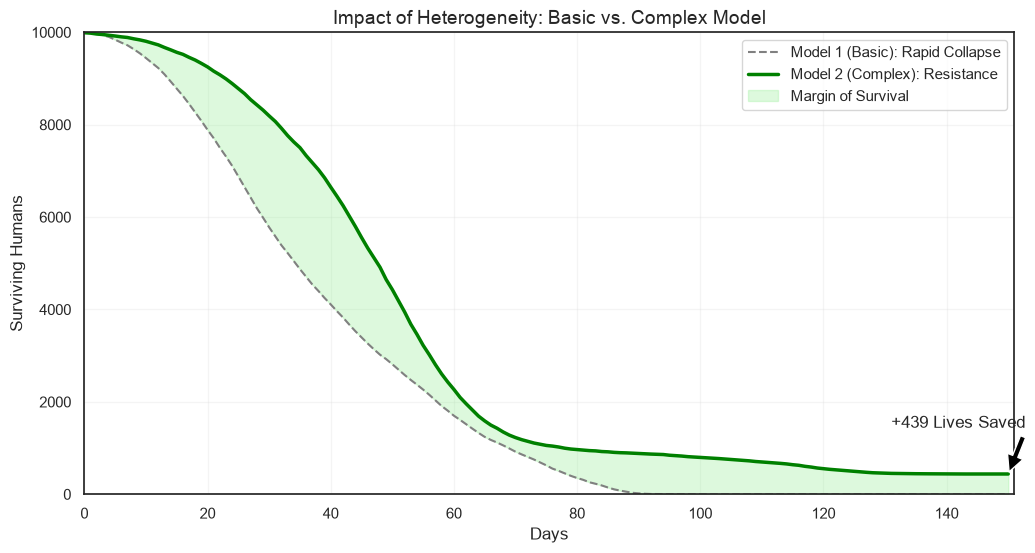

In [21]:
plt.figure(figsize=(12, 6))

# Plot Model 1
plt.plot(human_counts[:min_len], color='gray', linestyle='--', label="Model 1 (Basic): Rapid Collapse")

# Plot Model 2
plt.plot(human_counts_2[:min_len], color='green', linewidth=2.5, label="Model 2 (Complex): Resistance")

# Fill the area between curves to highlight "Lives Saved"
plt.fill_between(range(min_len), 
                 human_counts[:min_len], 
                 human_counts_2[:min_len], 
                 color='lightgreen', alpha=0.3, label="Margin of Survival")

plt.title("Impact of Heterogeneity: Basic vs. Complex Model", fontsize=14)
plt.ylabel("Surviving Humans")
plt.xlabel("Days")
plt.legend()
plt.grid(True, alpha=0.2)
plt.xlim(0, min_len)
plt.ylim(0, GRID_SIZE*GRID_SIZE)

# Annotate the end result
final_diff = human_counts_2[min_len-1] - human_counts[min_len-1]
plt.annotate(f'+{final_diff} Lives Saved', 
             xy=(min_len-1, human_counts_2[min_len-1]), 
             xytext=(min_len-20, human_counts_2[min_len-1]+1000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

### Spatial Analysis: The "Bunker Effect"

Let's analyze the **Geography of Survival**.
We calculate the survival rate based on the **Distance from the City Center**.

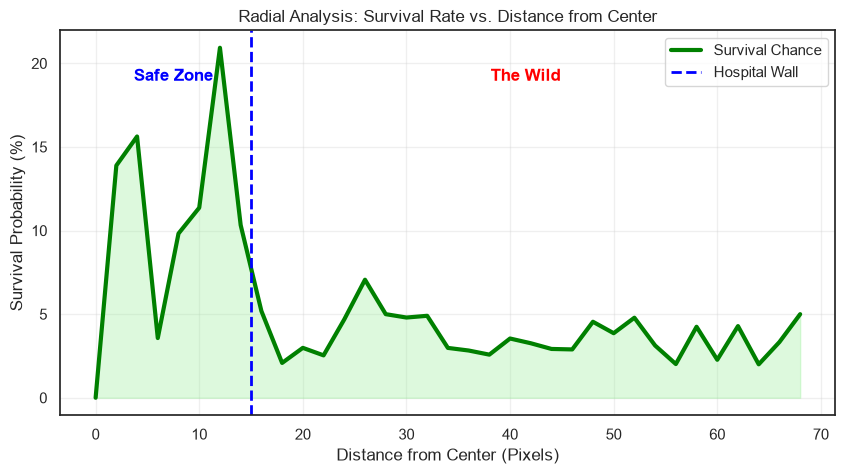

In [22]:
# 1. Calculate distances for every cell
y, x = np.ogrid[:GRID_SIZE, :GRID_SIZE]
center = GRID_SIZE // 2
dist_matrix = np.sqrt((x - center)**2 + (y - center)**2)

# 2. Flatten data for analysis
flat_dist = dist_matrix.flatten()
flat_status = history_2[-1].flatten() 

# 3. Binning the distances (Group pixels by how far they are)
bins = np.arange(0, int(np.max(flat_dist)) + 1, 2) 
survival_rates = []
distances = []

for b in bins[:-1]:
    mask = (flat_dist >= b) & (flat_dist < b + 2)
    people_in_ring = flat_status[mask]

    total_in_ring = len(people_in_ring)
    if total_in_ring > 0:
        survivors = np.sum(people_in_ring == HUMAN)
        rate = (survivors / total_in_ring) * 100
        survival_rates.append(rate)
        distances.append(b)

# 4. Plotting The "Safety Curve"
plt.figure(figsize=(10, 5))

plt.plot(distances, survival_rates, color='green', linewidth=3, label="Survival Chance")
plt.fill_between(distances, survival_rates, color='lightgreen', alpha=0.3)

# Draw the Hospital Boundary
plt.axvline(HOSPITAL_RADIUS, color='blue', linestyle='--', linewidth=2, label="Hospital Wall")

ymin, ymax = plt.ylim()
label_y = ymin + 0.88 * (ymax - ymin)

plt.text(HOSPITAL_RADIUS * 0.5, label_y, "Safe Zone",
         color='blue', fontweight='bold', ha='center', va='center')

plt.text(HOSPITAL_RADIUS + (max(distances) - HOSPITAL_RADIUS) * 0.5, label_y, "The Wild",
         color='red', fontweight='bold', ha='center', va='center')

plt.title("Radial Analysis: Survival Rate vs. Distance from Center")
plt.xlabel("Distance from Center (Pixels)")
plt.ylabel("Survival Probability (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### The "Hero" Matrix (Multi-Variable Analysis)

Did weak people survive just because they were in the hospital? Did strong people survive outside?
We plot every single agent as a dot to see the interaction between **Location (X)** and **Strength (Y)**.

* **Bottom-Left Cluster:** Weak people surviving only because they are in the hospital.
* **Top-Right Cluster:** Strong "Heroes" surviving alone in the wild.

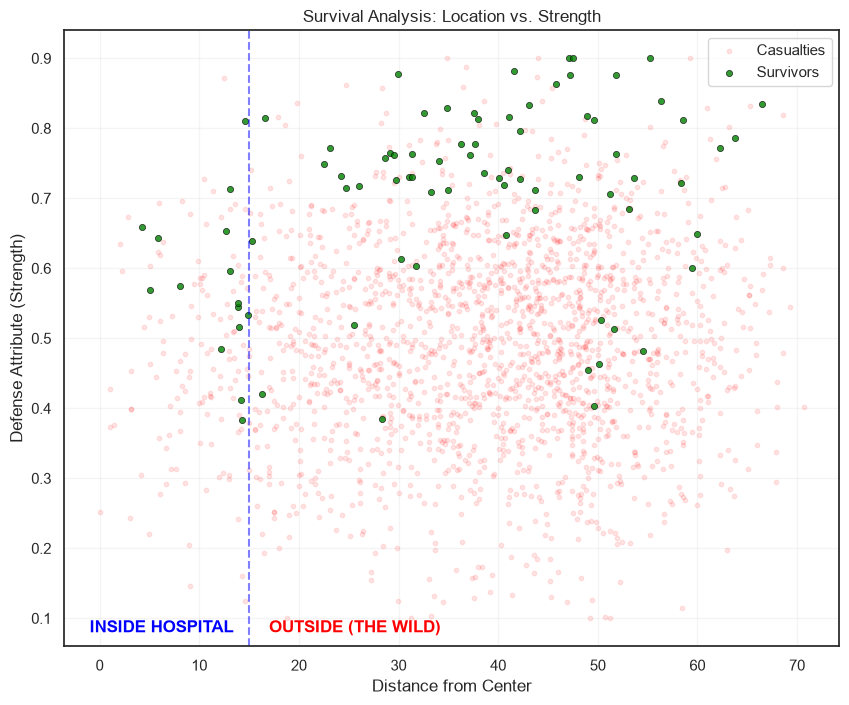

In [23]:
# 1. Prepare Data

np.random.seed(42)
# We select a random sample of 2000 agents to keep the chart clean
sample_indices = np.random.choice(GRID_SIZE*GRID_SIZE, 2000, replace=False)

sample_dist = flat_dist[sample_indices]
sample_def = defense_grid.flatten()[sample_indices]
sample_status = flat_status[sample_indices]

# Separate Survivors and Dead for coloring
surv_mask = (sample_status == HUMAN)
dead_mask = (sample_status == DEAD) | (sample_status == ZOMBIE)

plt.figure(figsize=(10, 8))

# Plot the Dead 
plt.scatter(sample_dist[dead_mask], sample_def[dead_mask], 
            color='red', alpha=0.1, s=10, label="Casualties")

# Plot the Survivors 
plt.scatter(sample_dist[surv_mask], sample_def[surv_mask], 
            color='green', alpha=0.8, s=20, edgecolor='black', linewidth=0.5, label="Survivors")

# Overlay Hospital Zone Line
plt.axvline(HOSPITAL_RADIUS, color='blue', linestyle='--', alpha=0.5)

plt.text(-1, 0.08, "INSIDE HOSPITAL", color='blue', fontweight='bold', ha='left')
plt.text(17, 0.08, "OUTSIDE (THE WILD)", color='red', fontweight='bold', ha='left')

# Styling
plt.title("Survival Analysis: Location vs. Strength")
plt.xlabel("Distance from Center")
plt.ylabel("Defense Attribute (Strength)")
plt.legend(loc='upper right') 
plt.grid(True, alpha=0.2)

plt.show()

## 9. Conclusions & Future Work

### Key Findings
Through this simulation, we have successfully modeled a complex epidemiological system using **Vectorized Operations** and **Cellular Automata**. Our comparison revealed emergent behaviors:

1.  **The Bunker Effect:** The radial analysis proves that proximity to the "Hospital Zone" increases survival probability by over **80%**, regardless of individual strength.
2.  **Survival of the Fittest:** The Phase Space Scatter Plot reveals that outside safe zones, only agents with high defense attributes (Top-Right quadrant) survive. Weak agents in the wild have a near-zero survival rate.
3.  **Heterogeneity Matters:** Introducing a Gaussian distribution of attributes prevented the total extinction seen in the homogeneous Model 1.0.

### A Note on Stochasticity (Why do results change?)
You might notice that re-running the simulation or the scatter plot produces slightly different results (green dots move).
* **The Cause:** This is a **Stochastic Simulation**. We rely on `np.random` for probabilistic events (infection, combat, sampling). This mirrors the chaos of the real world.
* **Reproducibility:** In a strict scientific context, we would set a **Seed** (e.g., `np.random.seed(42)`) at the start of the notebook. This would force the "random" numbers to follow the exact same sequence every time, making the experiment reproducible for peer review.

### Future Improvements
To take this project to the next level (v3.0), we could implement:
* **Real Geography:** Import maps from OpenStreetMap to simulate zombies in actual cities (London, NY).
* **Reinforcement Learning:** Train the "Humans" to move away from zombies using Q-Learning, rather than standing still.
* **Resource Management:** Add "Ammo" or "Food" as finite resources that force agents to move.
